In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.model_selection as skm
from itertools import product
from scipy.stats import uniform, randint



from sklearn.metrics import (accuracy_score, log_loss, roc_curve,
                              roc_auc_score, classification_report,
                              confusion_matrix, f1_score, matthews_corrcoef)

from sklearn.ensemble import (RandomForestRegressor as RF,
                               RandomForestClassifier as RFC)

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (cross_val_score, GridSearchCV,
                                      StratifiedKFold, RandomizedSearchCV)
from sklearn.calibration import calibration_curve
from scipy.stats import uniform, randint

from matplotlib.pyplot import subplots
from ISLP import load_data

import xgboost as xgb

okabe_ito = {
    "orange":    "#E69F00",
    "sky_blue":  "#56B4E9",
    "green":     "#009E73",
    "yellow":    "#F0E442",
    "blue":      "#0072B2",
    "vermilion": "#D55E00",
    "pink":      "#CC79A7",
    "black":     "#000000",
}

oi_colors = list(okabe_ito.values())

In [5]:
taiwan_credit = pd.read_csv("/home/georgehagstrom/work/Teaching/DATA622Spring2026/website/meetups/meetup-9/UCI_Credit_Card.csv")

X = taiwan_credit.drop(columns=["ID","default.payment.next.month"])

y = taiwan_credit["default.payment.next.month"]

feature_names = list(X.columns)

class_names = ["No Default","Default"]


X_train, X_test, y_train, y_test = skm.train_test_split(X,y,test_size = 0.2, random_state = 1001,stratify=y)



In [6]:
correlations = X_train.corrwith(y_train)
top_correlations = correlations.abs().sort_values(ascending=False).head(15)

correlations = correlations[top_correlations.index].to_frame(name="Correlation")
correlations.head(15)

,Correlation
PAY_0,0.327770
PAY_2,0.263590
PAY_3,0.235160
PAY_4,0.218304
PAY_5,0.206920
PAY_6,0.188902
LIMIT_BAL,-0.155912
PAY_AMT1,-0.070510
PAY_AMT5,-0.056307
PAY_AMT2,-0.055253


In [8]:
learning_rates = [0.005,0.01,0.025,0.05,0.1,0.2,0.3]

dtrain = xgb.DMatrix(X_train,label=y_train)

results = []

for lr in learning_rates:
    
    cv_results = xgb.cv(
    
        params = {"max_depth":3,"learning_rate":lr,"objective":"binary:logistic"},
        dtrain = dtrain,
        num_boost_round = 5000,
        nfold = 5,
        early_stopping_rounds = 50,
        seed = 10
    )

    results.append({"learning_rate":lr,
                   "cv_logloss":cv_results["test-logloss-mean"].min(),
                   "n_trees":cv_results.shape[0]
    })

result_df = pd.DataFrame(results)

results_df
    



NameError: name 'results_df' is not defined

In [12]:
results_df = result_df

opt_row = results_df.loc[results_df['cv_logloss'].idxmin()]

In [21]:

X_sub, X_es, y_sub, y_es = skm.train_test_split(
    X_train, y_train, test_size=0.15, random_state=1111, stratify=y_train
)


final_model = xgb.XGBClassifier(
    n_estimators=5000,
    max_depth=3,
    learning_rate=opt_row['learning_rate'],
    early_stopping_rounds=50,
    eval_metric='logloss',
    random_state=30,
    verbosity=0
)

final_model.fit(X_sub,y_sub,eval_set = [(X_es,y_es)],verbose=False)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [22]:
log_loss(y_test, final_model.predict_proba(X_test))

0.43371227857512723

In [24]:
accuracy_score(y_test, final_model.predict(X_test))

0.82

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

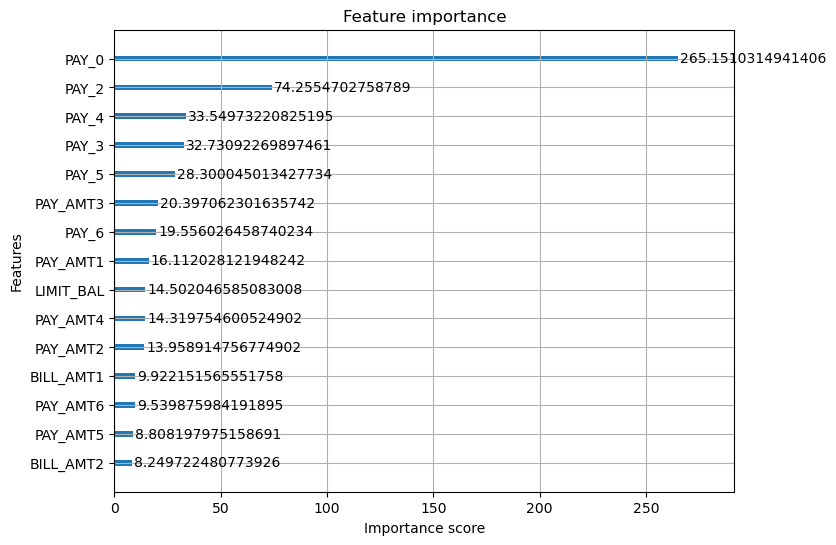

In [26]:
fig, ax = plt.subplots(figsize = (8,6))

xgb.plot_importance(final_model, ax = ax, max_num_features = 15, importance_type = 'gain')

In [28]:
param_grid = {
    'max_depth': [3,4,5,6],
    'learning_rate':[0.005,0.01,0.025,0.05,0.1,0.2,0.3]
}


cv_records = []

dtrain = xgb.DMatrix(X_train,label=y_train)


for combo in product(*param_grid.values()):
    params = dict(zip(param_grid.keys(),combo))

    cv_results = xgb.cv(
        params = {
            "objective":"binary:logistic",
            **params
        },
        dtrain = dtrain,
        num_boost_round = 5000,
        nfold = 5,
        early_stopping_rounds = 50,
        seed =3,
        verbose_eval = False
    )


    cv_records.append({**params,
                   "cv_logloss":cv_results["test-logloss-mean"].min(),
                   "n_trees":cv_results.shape[0]
    })


    



In [29]:
cv_df = pd.DataFrame(cv_records)

print(cv_df.sort_values('cv_logloss').head(10).to_string(index=False))

 max_depth  learning_rate  cv_logloss  n_trees
         4          0.025    0.426804      271
         4          0.010    0.426806      715
         4          0.005    0.426837     1377
         4          0.050    0.426870      133
         4          0.100    0.426901       63
         5          0.025    0.426930      199
         5          0.005    0.426942     1034
         5          0.010    0.426978      551
         3          0.005    0.427035     2333
         5          0.050    0.427085      110


In [30]:
best_row = cv_df.sort_values('cv_logloss').iloc[0]

best_params = {
    "max_depth": int(best_row["max_depth"]),
    "learning_rate": best_row["learning_rate"]
}

best_params

{'max_depth': 4, 'learning_rate': np.float64(0.025)}

In [31]:
final_tuned = xgb.XGBClassifier(
    n_estimators=5000,
    **best_params,
    early_stopping_rounds=50,
    eval_metric='logloss',
    random_state=91,
    verbosity=0
)

final_tuned.fit(X_sub,y_sub,eval_set = [(X_es,y_es)],verbose=False)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [32]:
final_tuned.best_iteration

255

In [33]:
log_loss(y_test,final_tuned.predict_proba(X_test))

0.43292643953795457

In [34]:
accuracy_score(y_test,final_tuned.predict(X_test))

0.8203333333333334

In [35]:
n_iter = 50

rng = np.random.default_rng(413242)
dtrain = xgb.DMatrix(X_train,label=y_train)

results = []

for i in range(n_iter):

    params = {
        "max_depth": rng.integers(3,9),
        "learning_rate": 10**(rng.uniform(-2, np.log10(0.3))),
        "subsample": rng.uniform(0.5,1.0),
        "colsample_bytree": rng.uniform(0.5,1.0),
        "min_child_weight": rng.choice([1,3,5,7,15]),
        "reg_lambda": 10**rng.uniform(-3,1)
    }

    cv_results = xgb.cv(
        params = {
            "objective":"binary:logistic",
            **params
        },
        dtrain = dtrain,
        num_boost_round = 5000,
        nfold = 5,
        early_stopping_rounds = 50,
        seed = 897,
        verbose_eval=False
    )

    results.append({**params,
    "cv_logloss":cv_results["test-logloss-mean"].min(),
    "num_trees":cv_results.shape[0]})

